## Monter Google Drive


In [1]:
#monter drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Objectif : Vérifier les versions de Python et TensorFlow

Cette cellule affiche les versions de Python et de TensorFlow utilisées dans l'environnement actuel. C'est utile pour s'assurer que les dépendances logicielles sont conformes aux attentes du projet.

In [2]:
import sys
import tensorflow as tf

print(f"Python Version: {sys.version}")
print(f"TensorFlow Version: {tf.__version__}")

Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow Version: 2.19.0


### Objectif : Définir les chemins des modèles

Cette cellule initialise les variables de chemin pour les modèles pré-entraînés (DenseNet, ResNet, EfficientNet) stockés sur Google Drive. Ces chemins seront utilisés plus tard pour charger les modèles.

In [3]:
densenet_path ='/content/drive/MyDrive/Colab Notebooks/Projet plantIA/DenseNet Model/densenet121_final.h5'
resnet_path ='/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/Copy of plant_disease_resnet50.h5'
efficientnet_path ='/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/plant_disease_efficientnetb0V2.h5'

### Objectif : Télécharger le jeu de données depuis Kagglehub

Cette cellule utilise la bibliothèque `kagglehub` pour télécharger et extraire le jeu de données 'plantvillage-split-70-15-15' de Kaggle. Ce jeu de données contient des images de plantes pour la classification des maladies.

In [4]:
import kagglehub
rabieoudghiri_plantvillage_split_70_15_15_path = kagglehub.dataset_download('rabieoudghiri/plantvillage-split-70-15-15')

print('Data source import complete.')

100%|██████████| 485M/485M [00:04<00:00, 127MB/s]

Extracting files...


Data source import complete.


### Objectif : Préparer le générateur d'images pour le jeu de test

Cette cellule configure un `ImageDataGenerator` pour le jeu de données de test. Elle définit le répertoire des images de test, applique un rééchelonnement des pixels et configure le générateur pour charger les images avec des paramètres spécifiques (taille cible, taille de lot, mode de classe et sans mélange pour un ordre déterministe).

In [5]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

test_dir = '/kaggle/input/plantvillage-split-70-15-15/plantvillage_split/test'
base_data_path = rabieoudghiri_plantvillage_split_70_15_15_path
test_dir = os.path.join(base_data_path, 'plantvillage_split', 'test')

# Pour ResNet
test_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

# Pour EfficientNet
test_gen_efficient = ImageDataGenerator(preprocessing_function=efficient_preprocess)

# Pour DenseNet (même logique que ResNet, valeurs ImageNet)

test_gen_densenet = ImageDataGenerator(preprocessing_function=densenet_preprocess)

test_generator_densenet = test_gen_densenet.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator_resnet = test_gen_resnet.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator_efficientnet = test_gen_efficient.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

#print(test_generator.filepaths[:5])
file_save_names = open('/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/file_path_names.txt','w')
for f_path in test_generator_efficientnet.filepaths:
    #print(f_path)
    file_save_names.write(f_path + '\n')
file_save_names.close()
print("Sauvgarde les chemins avec succes")

Found 8180 images belonging to 38 classes.
Found 8180 images belonging to 38 classes.
Found 8180 images belonging to 38 classes.
Sauvgarde les chemins avec succes


### Objectif : Charger les modèles pré-entraînés

Cette cellule charge les modèles de réseaux neuronaux DenseNet121, ResNet50 et EfficientNetB0 à partir de leurs chemins de fichiers spécifiés. Ces modèles sont ensuite prêts à être utilisés pour faire des prédictions.

In [6]:
from tensorflow.keras.models import load_model

# Load the DenseNet model
densenet_model = load_model(densenet_path)

# Load the ResNet model
resnet_model = load_model(resnet_path)

# Load the EfficientNet model
efficientnet_model = load_model(efficientnet_path)

print("DenseNet, ResNet, and EfficientNet models loaded successfully.")

DenseNet, ResNet, and EfficientNet models loaded successfully.


### Objectif : Effectuer des prédictions et les sauvegarder

Cette cellule utilise chaque modèle chargé pour générer des prédictions sur l'ensemble de test. Les résultats (probabilités de classe pour chaque image) sont ensuite sauvegardés en tant que fichiers `.npy` dans un répertoire spécifié pour une utilisation ultérieure, par exemple pour l'agrégation par vote souple.

In [7]:
print("Predictions avec Densenet121 :")
densenet_pred = densenet_model.predict(test_generator_densenet)
print("Predictions avec ResNet50 :")
resnet_pred = resnet_model.predict(test_generator_resnet)
print("Predictions avec EfficientNetB")
efficientnet_pred = efficientnet_model.predict(test_generator_efficientnet)

#os.makedirs('/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/predictions')
np.save('/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/predictions/densenet_predictions.npy',densenet_pred)
np.save('/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/predictions/resnet_predictions.npy',resnet_pred)
np.save('/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/predictions/efficientNet_predictions.npy',efficientnet_pred)

Predictions avec Densenet121 :


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


256/256 ━━━━━━━━━━━━━━━━━━━━ 54s 144ms/step
Predictions avec ResNet50 :
256/256 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step
Predictions avec EfficientNetB
256/256 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step


### Objectif : Charger les prédictions sauvegardées

Cette cellule charge les fichiers `.npy` contenant les prédictions de probabilité générées par chaque modèle (DenseNet, ResNet, EfficientNet) pour le jeu de test. Les formes des tableaux chargés sont ensuite affichées pour vérification.

In [8]:
import numpy as np

predictions_path = '/content/drive/MyDrive/Colab Notebooks/Projet plantIA/Voting/predictions/'

densenet_predictions_test = np.load(predictions_path + 'densenet_predictions.npy')
resnet_predictions_test = np.load(predictions_path + 'resnet_predictions.npy')
efficientnet_predictions_test = np.load(predictions_path + 'efficientNet_predictions.npy')

print("Loaded DenseNet predictions shape:", densenet_predictions_test.shape)
print("Loaded ResNet predictions shape:", resnet_predictions_test.shape)
print("Loaded EfficientNet predictions shape:", efficientnet_predictions_test.shape)

Loaded DenseNet predictions shape: (8180, 38)
Loaded ResNet predictions shape: (8180, 38)
Loaded EfficientNet predictions shape: (8180, 38)


### Objectif : Effectuer un vote souple et déterminer les classes prédites finales

Cette cellule implémente la stratégie de vote souple (soft voting) en moyennant les probabilités de classe prédites par DenseNet, ResNet et EfficientNet. Ensuite, elle détermine l'indice de la classe la plus probable pour chaque image de test et mappe ces indices aux noms de classe correspondants.

In [9]:
import numpy as np

# Ensure class_names is defined (it was defined in cell 6a460824)
class_names = [
        "Apple scab", "Apple Black rot", "Apple Cedar apple rust", "Apple healthy",
        "Blueberry healthy",
        "Cherry (including sour) Powdery mildew", "Cherry (including sour) healthy",
        "Corn (maize) Cercospora leaf spot Gray leaf spot", "Corn (maize) Common rust", "Corn (maize) Northern Leaf Blight", "Corn (maize) healthy",
        "Grape Black rot", "Grape Esca (Black Measles)", "Grape Leaf blight (Isariopsis Leaf Spot)", "Grape healthy",
        "Orange Huanglongbing (Citrus greening)",
        "Peach Bacterial spot", "Peach healthy",
        "Pepper bell Bacterial spot", "Pepper bell healthy",
        "Potato Early blight", "Potato Late blight", "Potato healthy",
        "Raspberry healthy",
        "Soybean healthy",
        "Squash Powdery mildew",
        "Strawberry Leaf scorch", "Strawberry healthy",
        "Tomato Bacterial spot", "Tomato Early blight", "Tomato Late blight", "Tomato Leaf Mold",
        "Tomato Septoria leaf spot", "Tomato Spider mites Two-spotted spider mite", "Tomato Target Spot",
        "Tomato Tomato Yellow Leaf Curl Virus", "Tomato Tomato mosaic virus", "Tomato healthy"
  ]

# Perform soft voting by averaging the probabilities
soft_voting_predictions_test = (densenet_predictions_test + resnet_predictions_test + efficientnet_predictions_test) / 3.0

# Get the predicted class index for each image in the test set
predicted_class_indices_test = np.argmax(soft_voting_predictions_test, axis=1)

# Map the predicted indices to class names
final_predicted_classes_test = [class_names[idx] for idx in predicted_class_indices_test]

print(f"Shape of soft voting predictions for test set: {soft_voting_predictions_test.shape}")
print(f"First 5 predicted class indices for test set: {predicted_class_indices_test[:5]}")
print(f"First 5 final predicted class names for test set: {final_predicted_classes_test[:5]}")

Shape of soft voting predictions for test set: (8180, 38)
First 5 predicted class indices for test set: [0 0 0 0 0]
First 5 final predicted class names for test set: ['Apple scab', 'Apple scab', 'Apple scab', 'Apple scab', 'Apple scab']


### Objectif : Trier et afficher les noms de classes

Cette cellule récupère les noms de classes à partir de l'objet `test_generator`, les trie par ordre alphabétique et affiche les cinq premiers noms de classes. Cela permet de vérifier l'ordre des classes tel qu'il est compris par le générateur.

In [10]:
import numpy as np

# Get class names from the test_generator.class_indices, which are already sorted alphabetically by default
sorted_class_names = sorted(test_generator_densenet.class_indices.keys())

# Display the first 5 sorted class names
print("First 5 class names in alphabetical order:")
for i, class_name in enumerate(sorted_class_names[:5]):
    print(f"{i+1}. {class_name}")

First 5 class names in alphabetical order:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy


### Objectif : Visualiser les probabilités des modèles individuels pour une image

Cette cellule extrait et trace les distributions de probabilité prédites par DenseNet, ResNet et EfficientNet pour une seule image de test. Cela permet de comparer visuellement la confiance et la distribution des prédictions de chaque modèle pour cet exemple particulier.

DenseNet Probabilities:


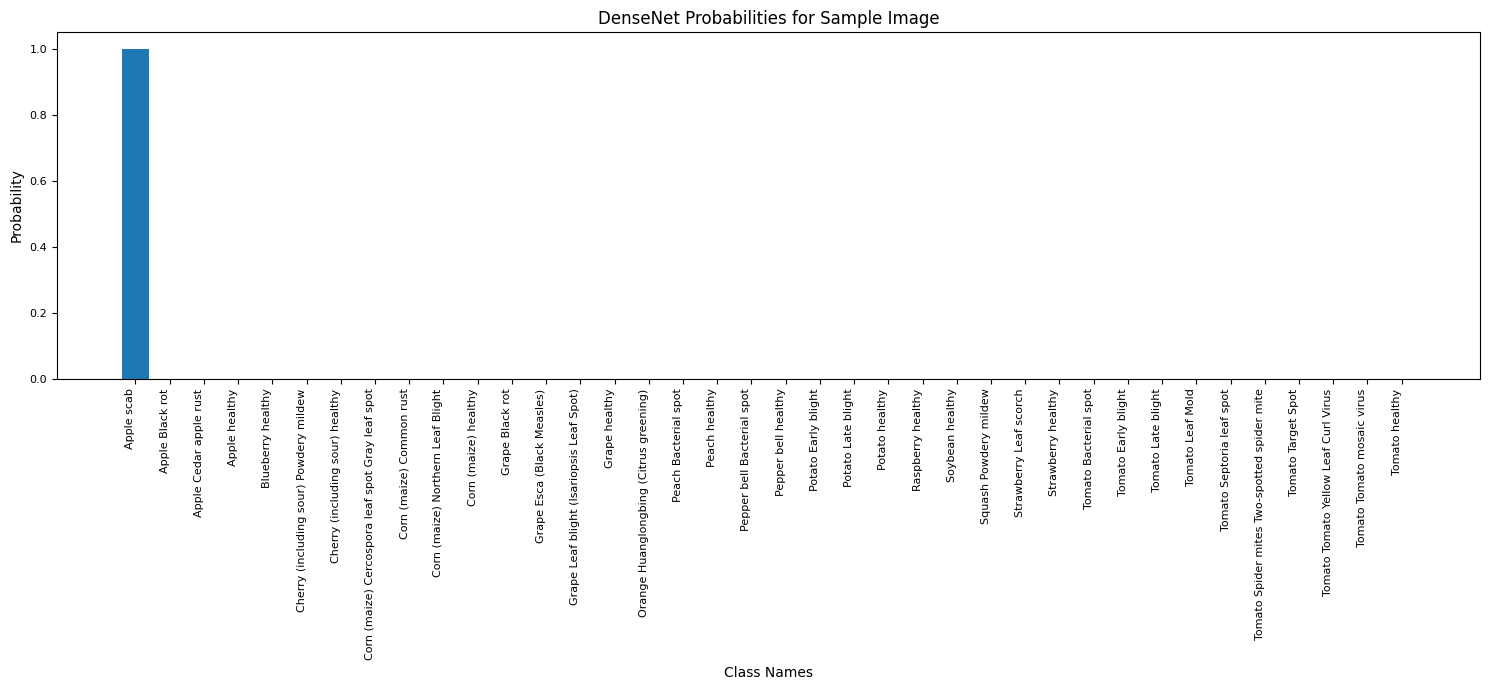

ResNet Probabilities:


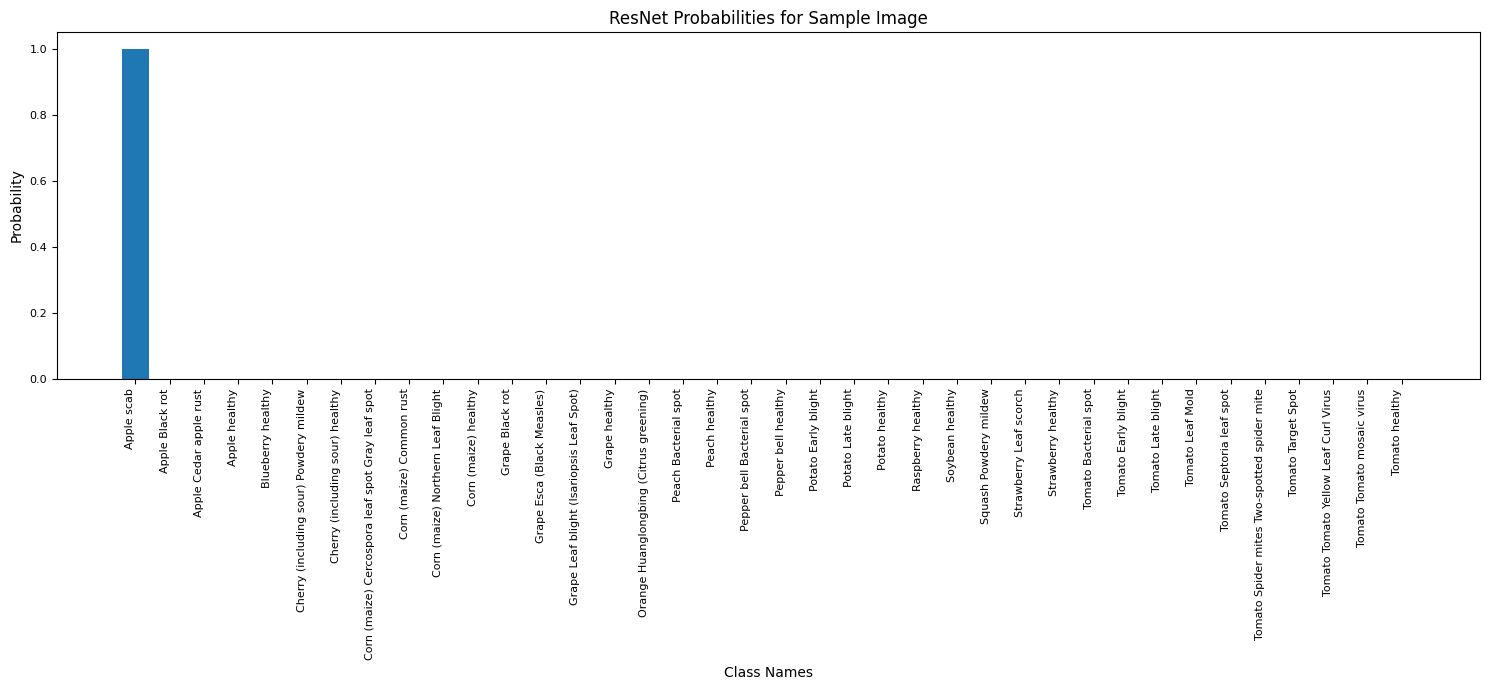

EfficientNet Probabilities:


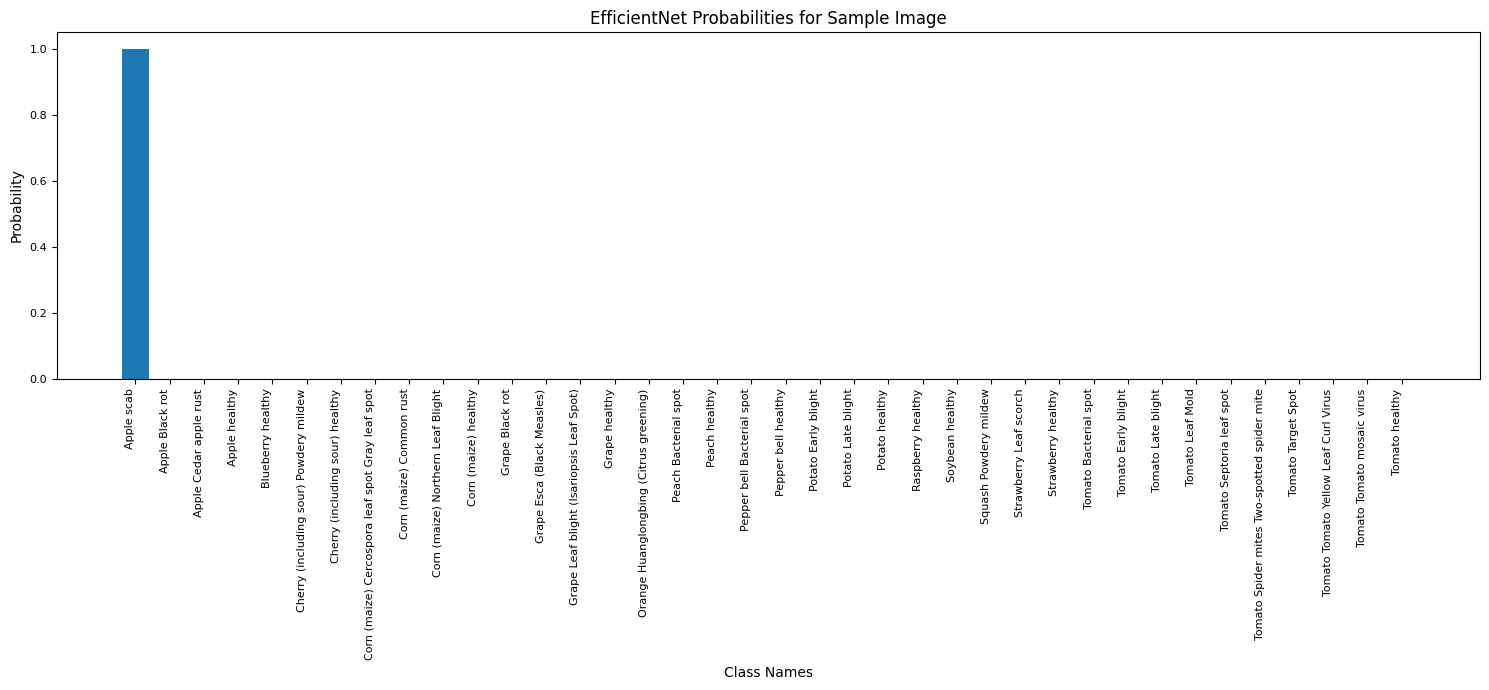

In [11]:
import matplotlib.pyplot as plt

# Select the predictions for the first sample (assuming _pred variables are already for a single image)
# As per the kernel state, densenet_pred, resnet_pred, efficientnet_pred already represent a single image prediction.
# We need to ensure they are 1D arrays for plotting, so we will use [0] to flatten the batch dimension.

densenet_probs = densenet_pred[0]
resnet_probs = resnet_pred[0]
efficientnet_probs = efficientnet_pred[0]

# Helper function to plot probabilities
def plot_probabilities(probabilities, class_names, title):
    plt.figure(figsize=(15, 7)) # Adjust figure size for better readability
    plt.bar(class_names, probabilities)
    plt.title(title)
    plt.xlabel('Class Names')
    plt.ylabel('Probability')
    plt.xticks(rotation=90, ha='right', fontsize=8) # Rotate labels and adjust font size
    plt.yticks(fontsize=8)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

# Plot DenseNet probabilities
print("DenseNet Probabilities:")
plot_probabilities(densenet_probs, class_names, 'DenseNet Probabilities for Sample Image')

# Plot ResNet probabilities
print("ResNet Probabilities:")
plot_probabilities(resnet_probs, class_names, 'ResNet Probabilities for Sample Image')

# Plot EfficientNet probabilities
print("EfficientNet Probabilities:")
plot_probabilities(efficientnet_probs, class_names, 'EfficientNet Probabilities for Sample Image')

## 1. Visualisation des probabilités des modèles individuels pour une image (barres graphiques), Analyse:
Ces trois graphiques à barres montrent la distribution des probabilités prédites par chaque modèle (DenseNet, ResNet, EfficientNet) pour une seule et même image de notre jeu de test. Voici ce que vous pouvez en déduire :

1.  **Confiance et 'netteté' des prédictions**: Regardez à quel point la barre de la classe prédite la plus élevée est haute par rapport aux autres. Si un modèle attribue une probabilité très élevée (proche de 1.0) à une seule classe et de très faibles probabilités aux autres, on dit qu'il a une prédiction 'nette' ou 'pointue'.

2.  **Distribution 'diffuse'** : Si un modèle distribue ses probabilités sur plusieurs classes, même si une classe est majoritaire, sa prédiction est plus 'diffuse'. Cela peut indiquer que le modèle est moins certain, ou qu'il perçoit des similarités entre plusieurs classes.

3.  **Désaccord/Complémentarité** : En comparant les trois graphiques, vous pouvez voir si les modèles sont d'accord sur la classe la plus probable. Même s'ils prédisent la même classe, leur niveau de confiance (la hauteur de la barre) peut varier, montrant la diversité de leurs 'opinions'.

Dans notre cas (pour l'image à l'index 0) :

Après les ajustements de prétraitement spécifiques à chaque modèle, DenseNet, ResNet et EfficientNet montrent tous des confiances très élevées pour la classe 'Apple scab' (proche de 1.0), avec des probabilités quasi nulles pour les autres classes. Tous les trois modèles agissent désormais comme des prédicteurs très 'nets' pour cette image, ce qui indique que le prétraitement adapté a permis à EfficientNet d'atteindre un niveau de confiance similaire aux autres sur cet exemple.

### Objectif : Visualiser la distribution des probabilités pour la classe prédite par l'ensemble

Cette cellule calcule et visualise la distribution des probabilités que chaque modèle individuel (DenseNet, ResNet, EfficientNet) a assignées à la classe finalement prédite par l'ensemble de vote souple, sur l'ensemble du jeu de données de test. Les diagrammes en boîte (`boxplot`) ou en violon sont utilisés pour montrer la répartition de ces confidences.

DenseNet ensemble probabilities shape: (8180,)
ResNet ensemble probabilities shape: (8180,)
EfficientNet ensemble probabilities shape: (8180,)


/tmp/ipykernel_1286/3923140471.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Probability', data=ensemble_probs_df, palette='viridis')


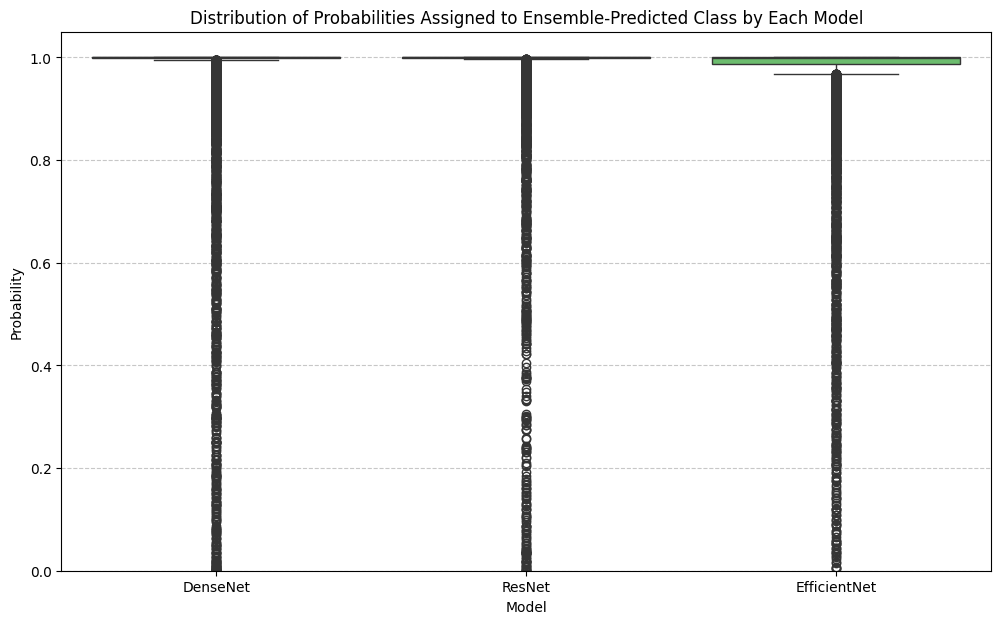

In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify the class predicted by the soft voting ensemble for each test image
#    This is already available in `predicted_class_indices_test`

# 2. Extract the probability each model assigned to this soft-voted predicted class
densenet_ensemble_probs = []
resnet_ensemble_probs = []
efficientnet_ensemble_probs = []

for i, predicted_class_idx in enumerate(predicted_class_indices_test):
    densenet_ensemble_probs.append(densenet_predictions_test[i, predicted_class_idx])
    resnet_ensemble_probs.append(resnet_predictions_test[i, predicted_class_idx])
    efficientnet_ensemble_probs.append(efficientnet_predictions_test[i, predicted_class_idx])

# Convert to numpy arrays for easier handling
densenet_ensemble_probs = np.array(densenet_ensemble_probs)
resnet_ensemble_probs = np.array(resnet_ensemble_probs)
efficientnet_ensemble_probs = np.array(efficientnet_ensemble_probs)

print(f"DenseNet ensemble probabilities shape: {densenet_ensemble_probs.shape}")
print(f"ResNet ensemble probabilities shape: {resnet_ensemble_probs.shape}")
print(f"EfficientNet ensemble probabilities shape: {efficientnet_ensemble_probs.shape}")

# 3. Create a DataFrame for easier plotting with seaborn
data = {
    'Model': ['DenseNet'] * len(densenet_ensemble_probs) +
             ['ResNet'] * len(resnet_ensemble_probs) +
             ['EfficientNet'] * len(efficientnet_ensemble_probs),
    'Probability': np.concatenate([
        densenet_ensemble_probs,
        resnet_ensemble_probs,
        efficientnet_ensemble_probs
    ])
}
ensemble_probs_df = pd.DataFrame(data)

# 4. Visualize the distribution of these probabilities using box plots
plt.figure(figsize=(12, 7))
sns.boxplot(x='Model', y='Probability', data=ensemble_probs_df, palette='viridis')
plt.title('Distribution of Probabilities Assigned to Ensemble-Predicted Class by Each Model')
plt.xlabel('Model')
plt.ylabel('Probability')
plt.ylim(0, 1.05) # Probabilities are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Visualisation de la distribution des probabilités assignées à la classe prédite par l'ensemble (Boîte à moustaches - Box Plot)

Ce graphique à boîtes est crucial car il montre la distribution des confiances de chaque modèle pour la classe finalement choisie par l'ensemble de vote souple, sur l'ensemble de notre jeu de données de test.

Voici comment interpréter les boîtes à moustaches pour chaque modèle (DenseNet, ResNet, EfficientNet) :

1.  **La médiane (ligne au centre de la boîte)** : Elle représente la confiance typique qu'un modèle a dans la classe que l'ensemble a choisie.

2.  **La boîte (intervalle interquartile - IQR)** : Elle couvre les 50% des observations centrales. Une boîte étroite indique que le modèle a une confiance assez constante. Une boîte large indique une variabilité plus importante. Les moustaches : Elles s'étendent pour montrer la plage de la plupart des données, en dehors de la boîte.

3.  **Les points (valeurs aberrantes/outliers)** : Ce sont les points individuels qui se situent en dehors des moustaches, indiquant des cas où le modèle a eu une confiance exceptionnellement basse ou haute pour la classe choisie par l'ensemble.

Dans notre cas :

DenseNet, ResNet et EfficientNet ont désormais tous des médianes de probabilité très élevées (proches de 1.0) pour la classe prédite par l'ensemble. Cela signifie que la plupart du temps, lorsque l'ensemble de vote souple prédit une classe, les trois modèles sont très confiants dans cette même classe. Leurs boîtes sont compactes et élevées, indiquant une confiance très constante et forte. Les ajustements de prétraitement ont visiblement amélioré la confiance et la cohérence d'EfficientNet.
Conclusion générale : Ces visualisations, après les corrections de prétraitement, montrent que l'ensemble bénéficie de trois modèles qui affichent des niveaux de confiance élevés et une bonne concordance pour la classe finale prédite par le vote souple. Tous contribuent fortement à la décision finale, avec moins de divergence dans les niveaux de confiance individuels par rapport aux observations initiales.